# A Prediction Model for the Real Estate Market

RealEstateAI Solutions aims to optimize real estate price evaluation through the use of advanced regularization techniques in linear regression models. The goal is to provide more accurate and reliable price predictions, reducing the risk of overfitting and improving the model's generalization capability.

In the real estate sector, obtaining accurate property price estimates is crucial for making informed decisions. However, traditional linear regression models can suffer from overfitting, compromising prediction accuracy. It is therefore necessary to explore effective regularization methods to improve predictive performance and manage model complexity.

By implementing and comparing regularization methods such as Lasso, Ridge, and Elastic Net, RealEstateAI Solutions will provide a system capable of delivering more accurate and stable real estate price predictions. This will allow real estate agents and investors to make decisions based on more reliable data, increasing their competitiveness in the market.

## Project Requirements:

### 1 - Dataset Preparation:

- Loading and preprocessing the real estate price data.

- Handling missing values, encoding categorical variables, and normalizing/scaling the data.

### 2 - Regression Model Implementation:

- Ridge Regression: Implementation and training of the model with Ridge regularization.

- Lasso Regression: Implementation and training of the model with Lasso regularization.

- Elastic Net Regression: Implementation and training of the model with Elastic Net regularization.

### 3 - Performance Evaluation:

- Use of cross-validation techniques.

- Calculation of the Mean Squared Error (MSE) for each model.

- Comparison of model complexity by evaluating the number of non-zero coefficients.

- Analysis and comparison of the results obtained with the different regularization methods.

### 4 - Results Visualization:

- Creation of charts to visualize and compare model performance.

- Visualization of the residual distribution to evaluate model adequacy.

The project must include the complete source code, with detailed comments explaining the various steps, the choices made, and the results obtained, in order to ensure transparency and reproducibility of the work.

## The Dataset

The dataset is available here: https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv (freely derived from the following dataset: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

- ****Price****: the price, the target to be predicted

- ****Area****: property area

- ****Bedrooms****: number of bedrooms

- ****Bathrooms****: number of bathrooms

- ****Stories****: number of floors

- ****Mainroad****: 1 if the property is located on a main road, 0 otherwise

- ****guestroom****: 1 if the property has a guest room, 0 otherwise

- ****basement****: 1 if the property has a basement, 0 otherwise

- ****hotwaterheating****: 1 if the property has a boiler, 0 otherwise

- ****airconditioning****: 1 if the property has air conditioning, 0 otherwise

- ****parking****: number of parking spaces

- ****prefarea****: 1 if the property is located in a prestigious area, 0 otherwise

- ****Furnishingstatus****: 0 if the property is unfurnished, 1 if it is semi-furnished, 2 if it is fully furnished.


## Initial setup and libraries import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

from sklearn.model_selection import learning_curve

## 1 - Dataset loading and preparation

In [2]:
# variable to hide debug prints or prints that do not show useful values for the analysis.
do_debug = True

In [3]:
# COSTANTI

# Set random seed for reproducibility
RANDOM_SEED = 0

# Price scaling for readability
PRICE_SCALE = 10000

# Alpha search - chosen as a constant to maintain uniformity across the various steps
ALPHA_GRID = np.logspace(-6, 6, 25)
if do_debug:
    print("Alpha interval:")
    print(f"Min: {ALPHA_GRID.min()}")
    print(f"Max: {ALPHA_GRID.max()}")
    print(f"Number of tested values: {len(ALPHA_GRID)}")

Alpha interval:
Min: 1e-06
Max: 1000000.0
Number of tested values: 25


In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading and preprocessing of housing price data.

In [5]:
# Dataset preview
BASE_URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/"

df = pd.read_csv(BASE_URL+"housing.csv")

if do_debug:
    df.head()

Preliminary prints for a quick glance.

In [6]:
if do_debug:
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [7]:
if do_debug:
    pd.options.display.float_format = '{:.2f}'.format
    df.describe()

### Handling missing values, encoding categorical variables, and data normalization/scaling.

In [8]:
# Handling missing values
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### Dummy encoding for Furnishingstatus

Currently **furnishingstatus** is an ordinal categorical variable with values 0/1/2. The goal is to have all categorical variables with binary values (0/1).

To achieve this, a one-hot encoding transformation will be applied.

We will use 0 (unfurnished) as the reference category.

Therefore, the model will be able to estimate:
- The effect of 1 (semi-furnished) compared to 0 (unfurnished),
- The effect of 2 (fully furnished) compared to 0.

In [9]:
# Transformation of categorical variables into dummy
X_categorical = df.drop("price", axis=1).copy()

# Let's transform furnishingstatus into dummy variables
X_categorical = pd.get_dummies(
    X_categorical,
    columns=["furnishingstatus"],
    prefix="furnishing",
    drop_first=True,
    dtype=int
)

if do_debug:
    print("Colonne finali:")
    print(X_categorical.columns.tolist())

    print("\nPrime righe:")
    print(X_categorical.head())

Colonne finali:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishing_1', 'furnishing_2']

Prime righe:
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishing_1  \
0                0                1        2         1             1   
1                0                1        3         0             1   
2                0                0        2         1             0   
3                0                1        3         1             1   
4 

### Exploratory analysis of the distribution and potential asymmetry for Area and Price.
- skewness difference calculation (relevance of asymmetry)
- visual check of price and area symmetry
- price-area correlation

In [10]:
# Skewness calculation (relevance asymmetry)
print("Skewness comparison")
print(f"Asimmetry Price: {df['price'].skew():.3f}")
print(f"Asimmetry Area: {df['area'].skew():.3f}")

Skewness comparison
Asimmetry Price: 1.212
Asimmetry Area: 1.321


Distribution Price and Area


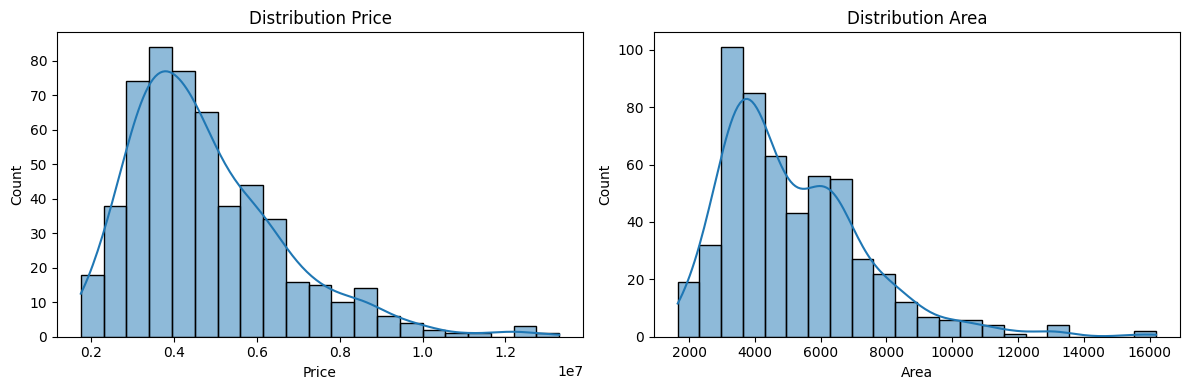

In [11]:
# visual check simmetry price e area

# grid creation for two plots
print("Distribution Price and Area")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# price distribution (first cell)
sns.histplot(df["price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution Price")
axes[0].set_xlabel("Price")

# area distribution (second cell)
sns.histplot(df["area"], kde=True, ax=axes[1])
axes[1].set_title("Distribution Area")
axes[1].set_xlabel("Area")

# grid visualization
plt.tight_layout()
plt.show()

Price - Area


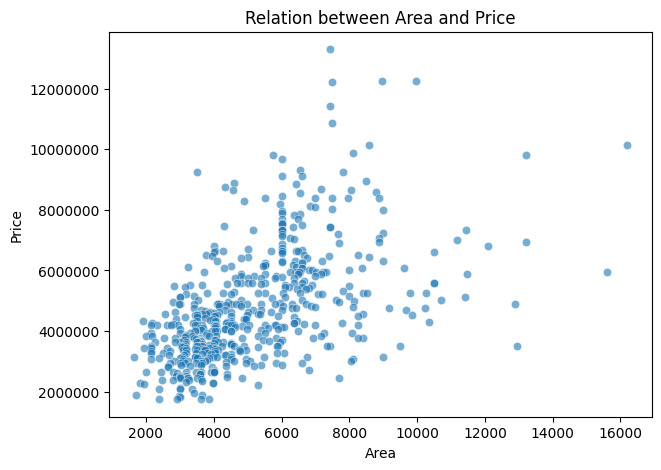

In [12]:
# correlation price-area

# Visualization of correlation price-area
print("Price - Area")
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="area", y="price", alpha=.6)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Relation between Area and Price")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

### Price and Area Exploration Comment
The Skewness result for checking asymmetry is greater than 0, meaning the mean is higher than the median (as also shown by the right-hand "tail" in the following plot, indicating right-skewness). More importantly it is greater than 1, which indicates that the asymmetry is highly significant—meaning the mean is much higher than the median.

Furthermore, the relationship between price and area shows a linear trend (analyzed later), though with scattered data points, particularly at higher values.

Based on these observations, several transformations (square root and logarithm) will be tested below on Price and Area to try and reduce skewness, using a Ridge model as the reference baseline.

## Price Transformation Analysis

In [13]:
# Analysis of Price Transformation

price_log = np.log1p(df["price"])
price_sqrt = np.sqrt(df["price"])

print(f"Skewness Price original: {df["price"].skew():.3f}")
print(f"Skewness log(Price): {price_log.skew():.3f}")
print(f"Skewness sqrt(Price): {price_sqrt.skew():.3f}")

Skewness Price original: 1.212
Skewness log(Price): 0.141
Skewness sqrt(Price): 0.660


In [14]:
# Function to isualize Price's distributions
def plot_distribution(original, log_transformed, sqrt_transformed, feature_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.histplot(original, kde=True, ax=axes[0])
    axes[0].set_title(f"{feature_name} originale")
    axes[0].set_xlabel(f"{feature_name} originale")

    sns.histplot(log_transformed, kde=True, ax=axes[1])
    axes[1].set_title(f"log({feature_name})")
    axes[1].set_xlabel(f"log({feature_name})")

    sns.histplot(sqrt_transformed, kde=True, ax=axes[2])
    axes[2].set_title(f"sqrt({feature_name})")
    axes[2].set_xlabel(f"log({feature_name})")

    plt.tight_layout()
    plt.show()

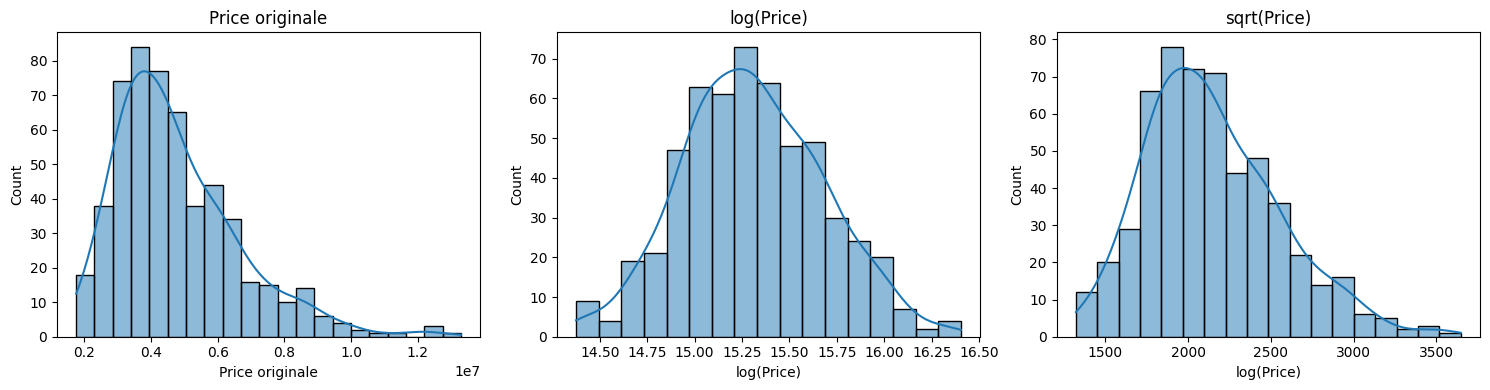

In [15]:
# Visualization of Price distributions
plot_distribution(df["price"], price_log, price_sqrt, "Price")

This analysis shows that the logarithmic transformation potentially has the best impact on skewness, as it reduces it the most.

Below we compare the three versions of **price** (original, log-transformed, and square-root-transformed) evaluated against a baseline model (Ridge) to determine which one is best for maximizing the model's predictive performance.

In [16]:
# Target in the three versions to compare
y_original = df["price"].values
y_log = np.log1p(df["price"]).values
y_sqrt = np.sqrt(df["price"]).values

if do_debug:
    print("Shape target original:", y_original.shape)
    print("Shape target log:", y_log.shape)
    print("Shape target sqrt:", y_sqrt.shape)

Shape target original: (545,)
Shape target log: (545,)
Shape target sqrt: (545,)


In [17]:
'''
Split train/test creating different y (target) for each scenarios (original, logarithm, square root)
'''
X = df.drop("price", axis=1).values

# Train/test split creation for the three target
X_train, X_test, y_original_train, y_original_test = train_test_split(
    X, # X = df.drop("price", axis=1).values
    y_original,
    test_size=.3,
    random_state=RANDOM_SEED
)

# Same values to obtain the corresponding logarithmic and square root targets
# logarithmic
_, _, y_log_train, y_log_test = train_test_split(
    X,
    y_log,
    test_size=.3,
    random_state=RANDOM_SEED
)
# square root
_, _, y_sqrt_train, y_sqrt_test = train_test_split(
    X,
    y_sqrt,
    test_size=.3,
    random_state=RANDOM_SEED
)

if do_debug:
    print("Train:", X_train.shape)
    print("Test:", X_test.shape)
    print("\n>> Targets:")
    print("y_original:", y_original_train.shape, y_original_test.shape)
    print("y_log:", y_log_train.shape, y_log_test.shape)
    print("y_sqrt:", y_sqrt_train.shape, y_sqrt_test.shape)

Train: (381, 12)
Test: (164, 12)

>> Targets:
y_original: (381,) (164,)
y_log: (381,) (164,)
y_sqrt: (381,) (164,)


In [18]:
'''
# Feature preparation
# NOTE: The X (features) are the same for all three experiments, so we apply PolynomialFeatures and StandardScaler only once.
'''

# Creating polynomial features to improve generalization
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Standardization - to normalize and bring values onto a common scale
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train_poly)
X_test_scaled = ss.transform(X_test_poly)

if do_debug:
    print("X train:", X_train_scaled.shape)
    print("X test:", X_test_scaled.shape)

X train: (381, 91)
X test: (164, 91)


Comparison of target transformations on Ridge used as a baseline

In [19]:
# original
model_ridge_original = RidgeCV(
    alphas=ALPHA_GRID,
    cv=5
)
model_ridge_original.fit(X_train_scaled, y_original_train)

# logarithmic
model_ridge_log = RidgeCV(
    alphas=ALPHA_GRID,
    cv=5
)
model_ridge_log.fit(X_train_scaled, y_log_train)

# square root
model_ridge_sqrt = RidgeCV(
    alphas=ALPHA_GRID,
    cv=5
)
model_ridge_sqrt.fit(X_train_scaled, y_sqrt_train)

if do_debug:
    print("Alpha original:", model_ridge_original.alpha_)
    print("Alpha log:", model_ridge_log.alpha_)
    print("Alpha sqrt:", model_ridge_sqrt.alpha_)

Alpha original: 316.22776601683796
Alpha log: 316.22776601683796
Alpha sqrt: 316.22776601683796


In [20]:
# General predictions
pred_original = model_ridge_original.predict(X_test_scaled)
pred_log = model_ridge_log.predict(X_test_scaled)
pred_sqrt = model_ridge_sqrt.predict(X_test_scaled)

# inverse transformation for logarithm and square root
pred_log_original = np.expm1(pred_log)
pred_sqrt_original = pred_sqrt ** 2

In [21]:
# Final comparison on the original Price scale
results = {
    "Price original": (
        np.sqrt(mean_squared_error(y_original_test, pred_original)),
        r2_score(y_original_test, pred_original)
    ),

    "Log(Price)": (
        np.sqrt(mean_squared_error(y_original_test, pred_log_original)),
        r2_score(y_original_test, pred_log_original)
    ),

    "Sqrt(Price)": (
        np.sqrt(mean_squared_error(y_original_test, pred_sqrt_original)),
        r2_score(y_original_test, pred_sqrt_original)
    )
}

for name, (rmse, r2) in results.items():
    print(f"\n{name}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")


Price original
RMSE: 932450.964
R²:   0.749

Log(Price)
RMSE: 1012276.918
R²:   0.705

Sqrt(Price)
RMSE: 936395.982
R²:   0.747


### Target Variable Transformation Comparison
Although both the logarithmic and square root transformations significantly reduce the skewness of the price distribution, the Ridge model trained on the original price achieves the best performance on the test set.

Therefore, the original target variable will be mantained for subsequent experiments.

## Area Transformation Analysis

### 1 - Trasformation with logarithm and square root

In [22]:
# Transformations analysis of Area
area_log = np.log1p(df["area"])
area_sqrt = np.sqrt(df["area"])

print(f"Skewness Area original: {df["area"].skew():.3f}")
print(f"Skewness log(Area): {area_log.skew():.3f}")
print(f"Skewness sqrt(Area): {area_sqrt.skew():.3f}")

Skewness Area original: 1.321
Skewness log(Area): 0.134
Skewness sqrt(Area): 0.683


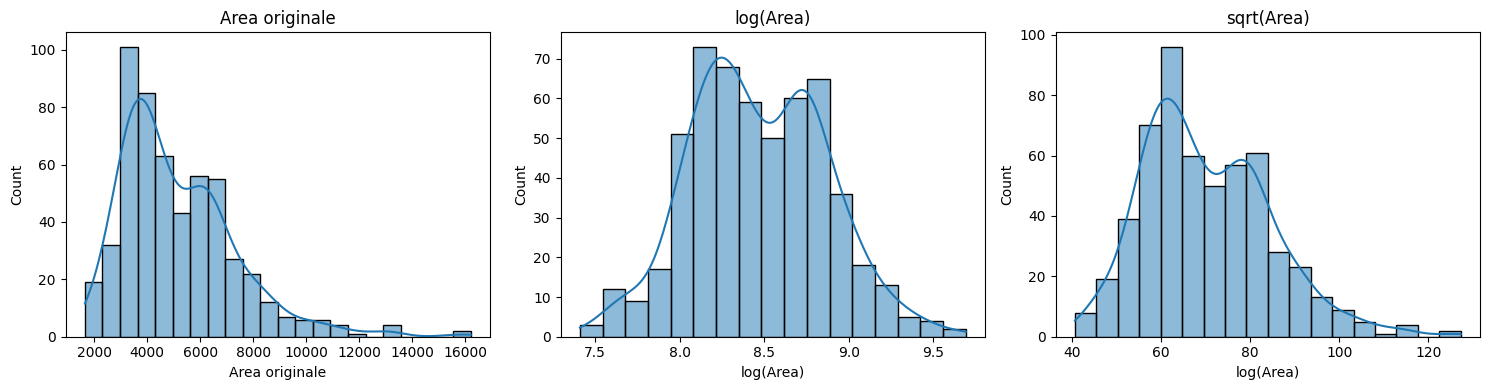

In [23]:
# Visualization of Area's transformations
plot_distribution(df["area"], area_log, area_sqrt, "Area")

The logarithmic transformation reduces skewness the most (the square root reduces it as well but much less).

Therefore, as with Price, log(Area) is the best candidate from a distributional perspective.

In [24]:
def train_ridge_area(X_train, X_test, y_train, y_test, alphas=ALPHA_GRID):

    poly_area = PolynomialFeatures(degree=2)

    X_train_poly = poly_area.fit_transform(X_train)
    X_test_poly = poly_area.transform(X_test)

    scaler_area = StandardScaler()

    X_train_scaled = scaler_area.fit_transform(X_train_poly)
    X_test_scaled = scaler_area.transform(X_test_poly)

    ridge_area = RidgeCV(
        alphas=alphas,
        cv=5
    )

    ridge_area.fit(X_train_scaled, y_train)

    y_pred = ridge_area.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return rmse, r2, ridge_area.alpha_

In [25]:
# Comparison of Area transformations in the Ridge model
X_original = df.drop("price", axis=1).copy()

X_log_area = X_original.copy()
X_log_area["area"] = np.log1p(X_log_area["area"])

X_sqrt_area = X_original.copy()
X_sqrt_area["area"] = np.sqrt(X_sqrt_area["area"])


# Use of the same split for all three scenarios
X_train_orig, X_test_orig, y_train_area, y_test_area = train_test_split(
    X_original.values,
    y_original,
    test_size=.3,
    random_state=RANDOM_SEED
)

X_train_log, X_test_log, _, _ = train_test_split(
    X_log_area.values,
    y_original,
    test_size=.3,
    random_state=RANDOM_SEED
)

X_train_sqrt, X_test_sqrt, _, _ = train_test_split(
    X_sqrt_area.values,
    y_original,
    test_size=.3,
    random_state=RANDOM_SEED
)

# Training of the three models
results_area = {}

results_area["Area originale"] = train_ridge_area(
    X_train_orig, X_test_orig,
    y_train_area, y_test_area
)

results_area["log(Area)"] = train_ridge_area(
    X_train_log, X_test_log,
    y_train_area, y_test_area
)

results_area["sqrt(Area)"] = train_ridge_area(
    X_train_sqrt, X_test_sqrt,
    y_train_area, y_test_area
)


# Results
for name, (rmse, r2, alpha) in results_area.items():
    print(f"\n{name}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")
    print(f"Alpha: {alpha}")


Area originale
RMSE: 932450.964
R²:   0.749
Alpha: 316.22776601683796

log(Area)
RMSE: 964820.521
R²:   0.732
Alpha: 316.22776601683796

sqrt(Area)
RMSE: 941330.279
R²:   0.745
Alpha: 316.22776601683796


Even in this case, transforming Area does not improve performance on Ridge; the original Area remains the best choice.

### 2 - Area trasformation using categorization:
- small
- medium
- large

In [26]:
# Categorization of Area in three groups
area_category = pd.qcut(
    df["area"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

print(area_category.value_counts().sort_index())

print("\nAverage price per category:")
print(df.groupby(area_category, observed=True)["price"].mean())

area
Small     184
Medium    179
Large     182
Name: count, dtype: int64

Average price per category:
area
Small    3566328.80
Medium   4527670.39
Large    6215439.23
Name: price, dtype: float64


This clearly reveals a relationship between price and area: as the area category increases, the average price increases (as previously observed in the correlation plot between Price and Area).

In [27]:
# Trasformation of Area in dummy variables
X_area_cat = df.drop("price", axis=1).copy()

X_area_cat["area_category"] = area_category

X_area_cat = pd.get_dummies(
    X_area_cat,
    columns=["area_category"],
    drop_first=True,
    dtype=int
)

if do_debug:
    print(X_area_cat.head())
    print("\nColumns:")
    print(X_area_cat.columns.tolist())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  \
0                0                1        2         1                 1   
1                0                1        3         0                 1   
2                0                0        2         1                 2   
3                0                1        3         1                 1   
4                0                1        2         0                 1   

   area_category_Medium  area_category_Large  
0                     0                    1  
1               

In [28]:
# Scaling the Price target for better readability
y_scaled = df["price"] / PRICE_SCALE

if do_debug:
    print("Price original:")
    print(df["price"].describe())

    print("\nPrice scaled:")
    print(y_scaled.describe())

Price original:
count        545.00
mean     4766729.25
std      1870439.62
min      1750000.00
25%      3430000.00
50%      4340000.00
75%      5740000.00
max     13300000.00
Name: price, dtype: float64

Price scaled:
count    545.00
mean     476.67
std      187.04
min      175.00
25%      343.00
50%      434.00
75%      574.00
max     1330.00
Name: price, dtype: float64


In [29]:
# Test Ridge using categorized Area
X_cat = X_area_cat.copy()

X_train_cat2, X_test_cat2, y_train_cat2, y_test_cat2 = train_test_split(
    X_cat,
    y_original,
    test_size=.3,
    random_state=RANDOM_SEED
)

rmse_cat2, r2_cat2, best_alpha_cat2 = train_ridge_area(
    X_train_cat2,
    X_test_cat2,
    y_train_cat2,
    y_test_cat2,
    ALPHA_GRID
)

print("Categorized Area")
print(f"RMSE:  {rmse_cat2:.3f}")
print(f"R²:    {r2_cat2:.3f}")
print(f"Alpha: {best_alpha_cat2}")

Categorized Area
RMSE:  915627.075
R²:    0.758
Alpha: 316.22776601683796


Area categorization is more effective than the logarithmic or square root transformations tested, at least for this Ridge model and configuration.

### Final comment to dataset preparation:

What emerges from the various transformations tested is that, at least for the Ridge baseline (not necessarily for other models), transformations on **Price** do not lead to useful improvements in terms of prediction, whereas operations on **Area** yield a predictive improvement when categorization is applied.

Consequently, for the subsequent modeling phase (Ridge, Lasso, and Elastic Net), the categorization of **Are** will be mantained alongside the one performed for **furnishingstatus**, while logarithmic and square-root transformations will not be used.


## 2 - Implementation of Regression Models (Ridge, Lasso, ElasticNet) :

In [30]:
def evaluate_model(
    model,
    model_name,
    X,
    y,
    target_scale=PRICE_SCALE
):
    y_pred_scaled = model.predict(X)

    y = y * target_scale
    y_pred = y_pred_scaled * target_scale

    rmse = np.sqrt(mean_squared_error(y, y_pred))

    r2 = r2_score(y, y_pred)

    print(f"\n{model_name} - extended alpha")
    print(f"Best alpha: {model.alpha_:.1f}")

    # per Elastic Net
    if hasattr(model, "l1_ratio_"):
        print(f"Best l1_ratio: {model.l1_ratio_}")

    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}")

    return rmse, r2

NOTE: for clarity and readability, the categorized 'furnishingstatus' and categorized 'Area' are rewritten below and then joined with X (features) for later use.

In [31]:
# Trasformation of furnishingstatus in dummy
X_combined = df.drop("price", axis=1).copy()

X_combined = pd.get_dummies(
    X_combined,
    columns=["furnishingstatus"],
    prefix="furnishing",
    drop_first=True,
    dtype=int
)

# Trasformation of Area in dummy
# Categorization of Area in three groups
area_category = pd.qcut(
    df["area"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

# Adding and dummy encoding of area_category starting from the previous dataset
X_combined["area_category"] = area_category

X_combined = pd.get_dummies(
    X_combined,
    columns=["area_category"],
    drop_first=True,
    dtype=int
)

# Elimination of generic column generica 'area' to avoid data duplication.
if "area" in X_combined.columns:
    X_combined = X_combined.drop("area", axis=1)

if do_debug:
    print("\n--- Final columns in combined dataset ---")
    print(X_combined.columns.tolist())
    print("\nFirst rows:")
    print(X_combined.head())


--- Final columns in combined dataset ---
['bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishing_1', 'furnishing_2', 'area_category_Medium', 'area_category_Large']

First rows:
   bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0         4          2        3         1          0         0   
1         4          4        4         1          0         0   
2         3          2        2         1          0         1   
3         4          2        2         1          0         1   
4         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishing_1  \
0                0                1        2         1             1   
1                0                1        3         0             1   
2                0                0        2         1             0   
3                0                1        3 

In [32]:
# Train/test split creation with categorized features
X_cat = X_combined.copy()

X_train_cat2, X_test_cat2, y_train_cat2, y_test_cat2 = train_test_split(
    X_cat,
    # y_original,
    y_scaled.values, # scaled
    test_size=.3,
    random_state=RANDOM_SEED
)

In [33]:
# Application of PolynomialFeatures and StandardScaler
poly_cat2 = PolynomialFeatures(degree=2)
X_train_poly = poly_cat2.fit_transform(X_train_cat2)
X_test_poly = poly_cat2.transform(X_test_cat2)

scaler_cat2 = StandardScaler()
X_train_scaled = scaler_cat2.fit_transform(X_train_poly)
X_test_scaled = scaler_cat2.transform(X_test_poly)

### Ridge

In [34]:
#Training of RidgeCV model on scaled data
ridge_model = RidgeCV(alphas=ALPHA_GRID, cv=5)
ridge_model.fit(X_train_scaled, y_train_cat2)

# Evaluation using evaluate_model (passing the scaled test data)
# Train
rmse_ridge_model_train, r2_ridge_model_train = evaluate_model(
    model=ridge_model,
    model_name="Ridge",
    X=X_train_scaled,
    y=y_train_cat2
)
# Test
rmse_ridge_model_test, r2_ridge_model_test = evaluate_model(
    model=ridge_model,
    model_name="Ridge",
    X=X_test_scaled,
    y=y_test_cat2
)



Ridge - extended alpha
Best alpha: 316.2
RMSE: 1023816.604
R²: 0.701

Ridge - extended alpha
Best alpha: 316.2
RMSE: 948638.871
R²: 0.741


### Lasso

In [35]:
lasso_model = LassoCV(alphas=ALPHA_GRID, cv=5, random_state=RANDOM_SEED, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train_cat2)

# Evaluation using evaluate_model (passing the scaled test data)
# Train
rmse_lasso_model_train, r2_lasso_model_train = evaluate_model(
    model=lasso_model,
    model_name="Lasso",
    X=X_train_scaled,
    y=y_train_cat2
)
# Test
rmse_lasso_model_test, r2_lasso_model_test = evaluate_model(
    model=lasso_model,
    model_name="Lasso",
    X=X_test_scaled,
    y=y_test_cat2
)


Lasso - extended alpha
Best alpha: 10.0
RMSE: 1054221.220
R²: 0.683

Lasso - extended alpha
Best alpha: 10.0
RMSE: 983130.910
R²: 0.721


### Elastic Net

In [36]:
elastic_model = ElasticNetCV(alphas=ALPHA_GRID, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=RANDOM_SEED, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train_cat2)

# Evaluation using evaluate_model (passing the scaled test data)
# Train
rmse_elastic_model_train, r2_elastic_model_train = evaluate_model(
    model=elastic_model,
    model_name="Elastic Net",
    X=X_train_scaled,
    y=y_train_cat2
)
# Test
rmse_elastic_model_test, r2_elastic_model_test = evaluate_model(
    model=elastic_model,
    model_name="Elastic Net",
    X=X_test_scaled,
    y=y_test_cat2
)


Elastic Net - extended alpha
Best alpha: 3.2
Best l1_ratio: 0.5
RMSE: 1059743.776
R²: 0.679

Elastic Net - extended alpha
Best alpha: 3.2
Best l1_ratio: 0.5
RMSE: 967688.952
R²: 0.730


In [37]:
# Compared visualization
models_results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "Alpha": [
        ridge_model.alpha_,
        lasso_model.alpha_,
        elastic_model.alpha_
    ],
    "RMSE_original_scale_train": [
        rmse_ridge_model_train,
        rmse_lasso_model_train,
        rmse_elastic_model_train,
    ],
    "RMSE_original_scale_test": [
        rmse_ridge_model_test,
        rmse_lasso_model_test,
        rmse_elastic_model_test
    ],
    "R2_train": [
        r2_ridge_model_train,
        r2_lasso_model_train,
        r2_elastic_model_train
    ],
    "R2_test": [
        r2_ridge_model_test,
        r2_lasso_model_test,
        r2_elastic_model_test
    ]
})

print(models_results)

         Model  Alpha  RMSE_original_scale_train  RMSE_original_scale_test  \
0        Ridge 316.23                 1023816.60                 948638.87   
1        Lasso  10.00                 1054221.22                 983130.91   
2  Elastic Net   3.16                 1059743.78                 967688.95   

   R2_train  R2_test  
0      0.70     0.74  
1      0.68     0.72  
2      0.68     0.73  


## First Evaluation Comments

The evaluation focuses on achieving the best generalization and minimum overfitting.

From this perspective, the results of this first evaluation show that:

- Ridge (Train = RMSE: 1023816.60, R2: 0.70 | Test = RMSE: 948638.87, R2: 0.74) is the best-performing model, achieving a good R2 that is higher on the test set than the training set, indicating the absence of overfitting.

- Elastic Net (Train = RMSE: 1059743.78, R2: 0.68 | Test = RMSE: 967688.95, R2: 0.73) comes very close to the Ridge results, proving to be stable but remaining slightly lower in terms of performance.

- Lasso (Train = RMSE: 1054221.22, R2: 0.68 | Test = RMSE: 983130.91, R2: 0.72) ranks as the least performant model of the group, though it also remains well-aligned and stable between the training and test sets.

## 3 - Performance Evaluation:

### - Use of cross-validation techniques.
### - Calculation of the Mean Squared Error (MSE) for each model.


In [38]:
# Use of cross-validation techniques (cross-validation).
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# we use the best alpha and l1_ratio values found previously.
models = {
  "Ridge": Ridge(alpha=ridge_model.alpha_),
  "Lasso": Lasso(alpha=lasso_model.alpha_),
  "ElasticNet": ElasticNet(alpha=elastic_model.alpha_, l1_ratio=elastic_model.l1_ratio_)
}

cv_results = {}

for name, model in models.items():
  # requested results
  train_mse_list = []
  test_mse_list = []
  non_zero_coefs_list = []
  # addictional results
  train_rmse_list = []
  test_rmse_list = []
  train_r2_list = []
  test_r2_list = []

  for train_index, test_index in kf.split(X_train_cat2):
    X_train_cv, X_test_cv = X_train_cat2.iloc[train_index], X_train_cat2.iloc[test_index] # iloc because X_train_cat2 is not a numpy.ndarray
    y_train_cv, y_test_cv = y_train_cat2[train_index], y_train_cat2[test_index]

    # Polynomial Features
    poly = PolynomialFeatures(degree=2)
    X_train_cv_poly = poly.fit_transform(X_train_cv)
    X_test_cv_poly = poly.transform(X_test_cv)

    # Standardizzazione
    ss = StandardScaler()
    X_train_cv_poly = ss.fit_transform(X_train_cv_poly)
    X_test_cv_poly = ss.transform(X_test_cv_poly)

    # Model fit
    model.fit(X_train_cv_poly, y_train_cv)

    y_train_pred = model.predict(X_train_cv_poly)
    y_test_pred = model.predict(X_test_cv_poly)

    # MSE calculation
    train_mse = mean_squared_error(y_train_cv, y_train_pred)
    test_mse = mean_squared_error(y_test_cv, y_test_pred)

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

    # Calculation of non-zero coefficients
    non_zero_count = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_count)

    # RMSE calculation
    train_rmse_list.append(np.sqrt(train_mse) * PRICE_SCALE)
    test_rmse_list.append(np.sqrt(test_mse) * PRICE_SCALE)

    # R2 calculation
    train_r2_list.append(r2_score(y_train_cv, y_train_pred))
    test_r2_list.append(r2_score(y_test_cv, y_test_pred))

  cv_results[name] = {
      # requested results
      "mse_train": np.mean(train_mse_list),
      "mse_test": np.mean(test_mse_list),
      "non_zero_coefs": np.mean(non_zero_coefs_list),
      # addictional results
      "rmse_train": np.mean(train_rmse_list),
      "rmse_test": np.mean(test_rmse_list),
      "r2_train": np.mean(train_r2_list),
      "r2_test": np.mean(test_r2_list),
      "overfitting": 1 - (np.mean(test_r2_list) / np.mean(train_r2_list))
  }


print("\nCross-Validation Results:")
for name, res in cv_results.items():
    print(f"--- {name} ---")
    print(f"MSE scaled (Train/Test): {res['mse_train']:.3f} / {res['mse_test']:.3f}")
    print(f"Non-zero coefficients (avg): {res['non_zero_coefs']:.1f}")
    print(f"RMSE original scale (Train/Test): {res['rmse_train']:.3f} / {res['rmse_test']:.3f}")
    print(f"R2 (Train/Test): {res['r2_train']:.3f} / {res['r2_test']:.3f}")
    print(f"Overfitting: {res['overfitting']:.3f}\n")


Cross-Validation Results:
--- Ridge ---
MSE scaled (Train/Test): 10290.689 / 13283.706
Non-zero coefficients (avg): 115.6
RMSE original scale (Train/Test): 1013836.254 / 1139977.961
R2 (Train/Test): 0.706 / 0.627
Overfitting: 0.113

--- Lasso ---
MSE scaled (Train/Test): 10723.268 / 14158.169
Non-zero coefficients (avg): 28.0
RMSE original scale (Train/Test): 1035042.730 / 1177326.939
R2 (Train/Test): 0.694 / 0.602
Overfitting: 0.132

--- ElasticNet ---
MSE scaled (Train/Test): 10917.813 / 13256.543
Non-zero coefficients (avg): 108.2
RMSE original scale (Train/Test): 1044272.361 / 1138267.452
R2 (Train/Test): 0.688 / 0.628
Overfitting: 0.088



## Post-Cross-Validation Performance Comments

Following cross-validation, Ridge and Elastic Net emerge as the best-performing models, reaching the same R2 on the Test Set (~ 0.63) and a nearly identical RMSE (~ 1.14 million on the original scale).

However, Elastic Net proves to be the best model in terms of stability, recording the lowest overall overfitting level (0.088).

It is worth noting that Elastic Net and Ridge maintain a very high number of active coefficients (108.2 and 115.6, respectively), whereas Lasso drastically reduces non-zero coefficients to just 28.0.

Therefore, even though it reduces model complexity, Lasso performs the worst in predictive metrics (Test R2 of 0.602) and exhibits the highest overfitting level (0.132) (although it still remains within an acceptable threshold).

### - Comparing model complexity by evaluating the number of non-zero coefficients.
### - Analysis and comparison of the results from the various regularization methods.

In [39]:
'''
Function to extract the most important features (with the largest absolute coefficient) for each model.
'''
def extract_top_features(model, model_name, poly_transformer, original_columns, top_n=5):
    # Names of generated feature by PolynomialFeatures
    feature_names = poly_transformer.get_feature_names_out(original_columns)

    # DataFrame with the coefficients of the model passed as parameter
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    # Absolute value and sorting
    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

    # 5 feature with higher absolute coefficients
    print(f"\n>> Top {top_n} Feature più influenti per {model_name}:")
    print(coef_df.head(top_n).to_string(index=False)) # to_string removes the index for a cleaner print
    print("\n")

    return coef_df

In [40]:
# visualization using abs because we are interested in which feature has the greatest impact in absolute value (whether positive or negative).
def plot_top_features(coef_df, model_name, top_n=5):
    top_coef = coef_df.head(top_n).sort_values("Abs_Coefficient")

    plt.figure(figsize=(8, 4))

    plt.barh(
        top_coef["Feature"],
        top_coef["Coefficient"]
    )

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Features with the highest weight - {model_name}")

    plt.tight_layout()
    plt.show()

In [41]:
'''
Group the importance of the original single features (after categorization, used with X_cat).
'''
def single_feature_importance(coef_df, original_df, model_name):
    original_features_cat = original_df.columns.tolist()
    importance_by_variable = {}

    for feature in original_features_cat:
        # mask = coef_df["Feature"].str.contains(
        #     feature,
        #     regex=False
        # )
        mask = coef_df["Feature"].apply(lambda x: feature in str(x).split())
        importance_by_variable[feature] = (
            coef_df.loc[mask, "Abs_Coefficient"].sum()
        )

    single_feature_importance = pd.DataFrame(
        list(importance_by_variable.items()),
        columns=["Variable", "Total_Abs_Coefficient"]
    )

    single_feature_imp = single_feature_importance.sort_values(
        "Total_Abs_Coefficient",
        ascending=False
    )

    print(f">> Feature SINGLE original (after categorization) most influential on {model_name}:")
    print(single_feature_imp.head(5).to_string(index=False))
    print("\n")

    return single_feature_importance

--- Ridge ---

Non-zero coefficients (avg): 115.6

> Feature COMBINED

>> Top 5 Feature più influenti per Ridge:
                      Feature  Coefficient  Abs_Coefficient
bathrooms area_category_Large        10.20            10.20
           bathrooms prefarea         9.22             9.22
     basement hotwaterheating         8.89             8.89
           bathrooms mainroad         8.62             8.62
    bathrooms airconditioning         8.48             8.48


>> 10 Feature LESS influential on Ridge (closer to zero):
                                 Feature  Coefficient  Abs_Coefficient
                        basement parking         0.23             0.23
                   basement furnishing_1         0.23             0.23
                    stories furnishing_1        -0.22             0.22
                     bathrooms guestroom         0.20             0.20
                  guestroom furnishing_1         0.10             0.10
                       stories guestroom 

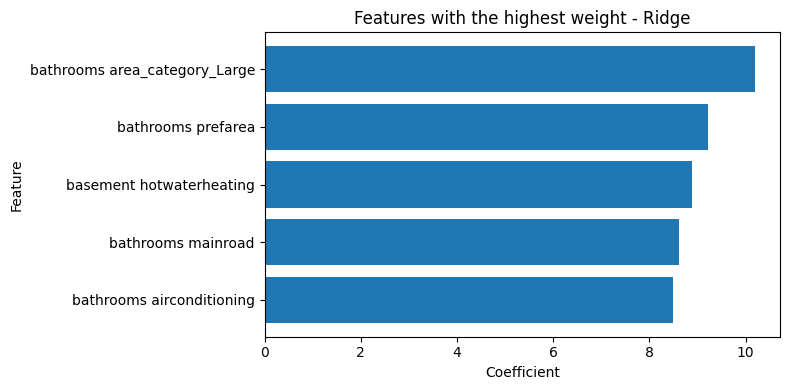

---------------------------------

--- Lasso ---

Non-zero coefficients (avg): 28.0

> Feature COMBINED

>> Top 5 Feature più influenti per Lasso:
                     Feature  Coefficient  Abs_Coefficient
          bathrooms prefarea        32.45            32.45
bedrooms area_category_Large        27.54            27.54
          bathrooms mainroad        24.25            24.25
   bathrooms airconditioning        21.22            21.22
           bathrooms parking        15.70            15.70


>> 10 Feature LESS influential on Lasso (closer to zero):
                                 Feature  Coefficient  Abs_Coefficient
                          furnishing_1^2         0.00             0.00
                   prefarea furnishing_2         0.00             0.00
               furnishing_1 furnishing_2         0.00             0.00
       furnishing_1 area_category_Medium         0.00             0.00
        furnishing_1 area_category_Large         0.00             0.00
       furnis

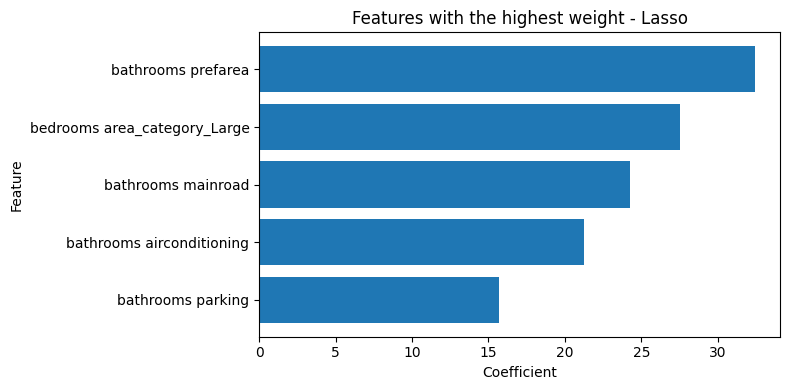

---------------------------------

--- Elastic Net ---


> Feature COMBINED

>> Top 5 Feature più influenti per Elastic Net:
                      Feature  Coefficient  Abs_Coefficient
bathrooms area_category_Large         8.35             8.35
           bathrooms mainroad         7.67             7.67
    bathrooms airconditioning         6.95             6.95
           bathrooms prefarea         6.94             6.94
 bedrooms area_category_Large         6.43             6.43


>> 10 Feature LESS influential on Elastic Net (closer to zero):
                                 Feature  Coefficient  Abs_Coefficient
                basement airconditioning         0.00             0.00
               guestroom hotwaterheating        -0.00             0.00
                    parking furnishing_2         0.00             0.00
                               parking^2         0.00             0.00
            airconditioning furnishing_2        -0.00             0.00
    hotwaterheating are

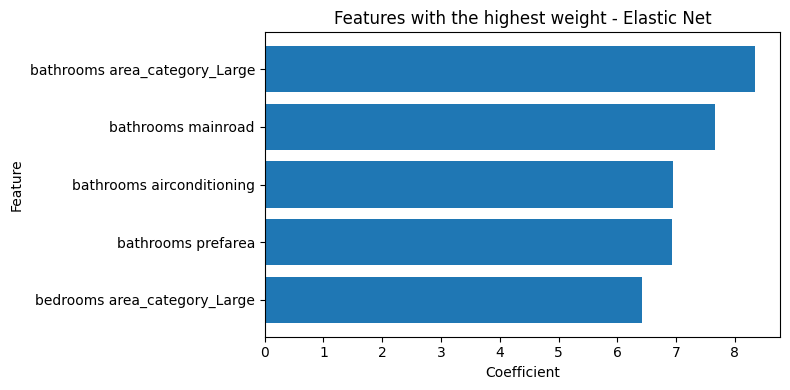

---------------------------------



In [42]:
models_to_analyse = {
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Elastic Net": elastic_model
}

# Loop to dynamically analyze each model
for name, instance in models_to_analyse.items():
    print(f"--- {name} ---\n")
    # non-zero coefficients
    if name in cv_results:
        print(f"Non-zero coefficients (avg): {cv_results[name]['non_zero_coefs']:.1f}")

    # feature COMBINED
    print("\n> Feature COMBINED")
    # most influential
    coef_df = extract_top_features(
        model=instance,
        model_name=name,
        poly_transformer=poly_cat2,
        original_columns=X_cat.columns,
        top_n=5
    )

    # less influential
    print(f">> 10 Feature LESS influential on {name} (closer to zero):")
    print(coef_df.tail(10).to_string(index=False))
    print("\n")

    # feature SINGLE original (after categorization)
    print("> Feature SINGLE")
    # most influential
    single_feature_imp = single_feature_importance(
        coef_df= coef_df,
        original_df= X_cat,  # X_cat to already have dummy furnishingstatus and Area
        model_name=name
    )

    # less influential
    print(f">> Feature SINGLE LESS influential on {name} (closer to zero):")
    # print(single_feature_imp.tail(10).to_string(index=False))
    print(single_feature_imp.tail(5).sort_values("Total_Abs_Coefficient", ascending=True).to_string(index=False))
    print("\n")

    # coefficients visualization in abs. NOTE: values on redued scale
    plot_top_features(coef_df, name)
    print(f"---------------------------------\n")

### Coefficient Analysis Comment:

Premise: The choice to use PolynomialFeatures(degree=2) to multiply all variables in pairs means that the coefficient evaluation also includes combined features (e.g., bathrooms area_category_Large).

This implies that the model discovered, for instance, that adding a bathroom in a large villa increases the house value much more than adding a bathroom in a small apartment—showing that a bathroom does not hold the same value across all types of properties.

Consequently, in addition to individual features (e.g., bathrooms), it is also crucial to consider the weight of their combinations (e.g., bathrooms area_category_Large).

That being said:
- **Zero Coefficients**: Lasso wins in terms of interpretability by zeroing out variables it deems unnecessary, removing noise, and making the results easier to understand. However, in doing so, it pays a price in predictive power compared to Ridge and Elastic Net, which perform better with a higher number of non-zero coefficients.

- **Most Relevant Features**: On an individual level, **bathrooms** is the most relevant variable for every model, as well as when combined with other features. Meanwhile, **area_category_Large** ranks in the top 3 for all models, both individually and in combination.

- **Least Relevant Features**: On an individual level, **furnishing_1** and **furnishing_2** are in the top 3 least relevant variables for all models. On a combined level, the number of features with values close to 0 is very high across all models.

## 4 - Results visualization:

### Creating plots to visualize and compare model performance.


---- Learning Curve : Ridge ----


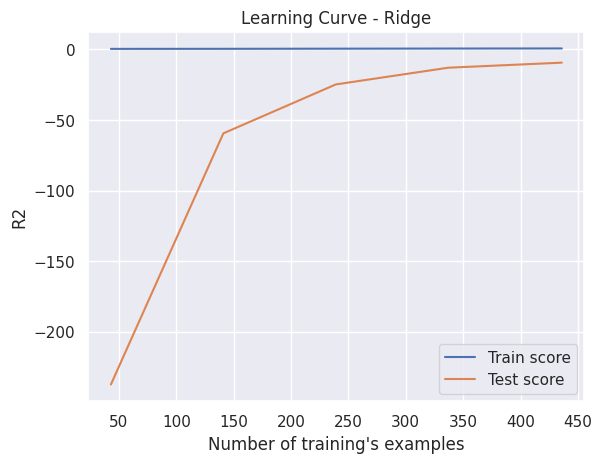


---- Learning Curve : Lasso ----


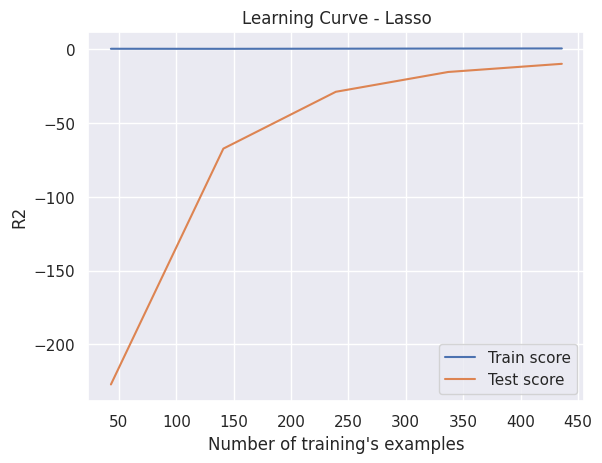


---- Learning Curve : ElasticNet ----


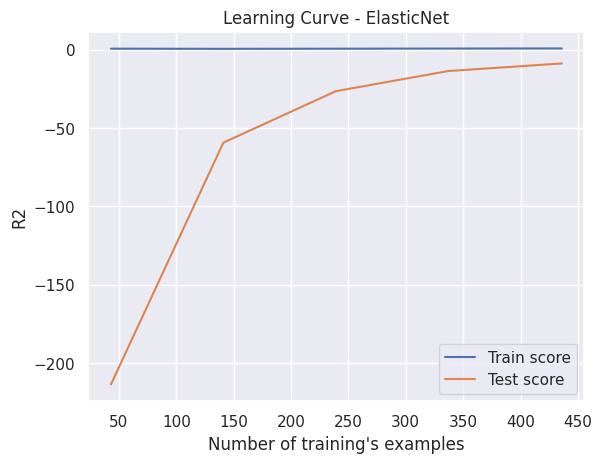

In [43]:
# Learning Curve visualization for each model
sns.set_theme()

for name, model in models.items():
    # Same pipeline used before
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    print(f"\n---- Learning Curve : {name} ----")

    train_sizes_abs, train_scores, test_scores = learning_curve(
        pipeline,
        X_cat,
        # y_original,
        y_scaled.values,
        cv=5,
        scoring="r2",
        random_state=RANDOM_SEED
    )

    plt.plot(train_sizes_abs, train_scores.mean(axis=1), label="Train score")
    plt.plot(train_sizes_abs, test_scores.mean(axis=1), label="Test score")
    plt.xlabel("Number of training's examples")
    plt.ylabel("R2")
    plt.title(f"Learning Curve - {name}")
    plt.legend()
    plt.show()

### Visualizing the residual distribution to evaluate model adequacy.

In [44]:
'''
Function to create the pipeline (Poly, Scaler, Modello), train the model,
calculate residuals on original scale and show the plot.
'''
def plot_residuals(model_instance, model_name, X_train, X_test, y_train, y_test, target_scale=PRICE_SCALE):
    # Complete pipeline
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", model_instance)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_scaled = pipeline.predict(X_test)

    # Prices brought back to original scale
    y_test_original = y_test * target_scale
    y_pred_original = y_pred_scaled * target_scale

    # Calculation of real residuals
    residuals = y_test_original - y_pred_original

    # plot
    plt.figure(figsize=(9, 5))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)

    # Formatting to avoid scientific notation (e.g., 1e6) on axes
    plt.ticklabel_format(style='plain', axis='both')

    plt.xlabel("Residuals (Real price - Predicted Price)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Residuals - {model_name} Regression")
    plt.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    return residuals


---- Generation Plot Residuals: Ridge ----


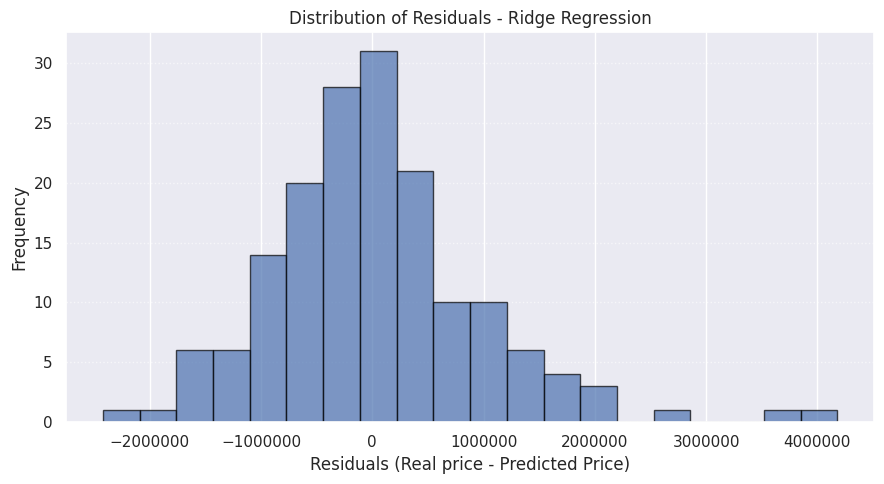


---- Generation Plot Residuals: Lasso ----


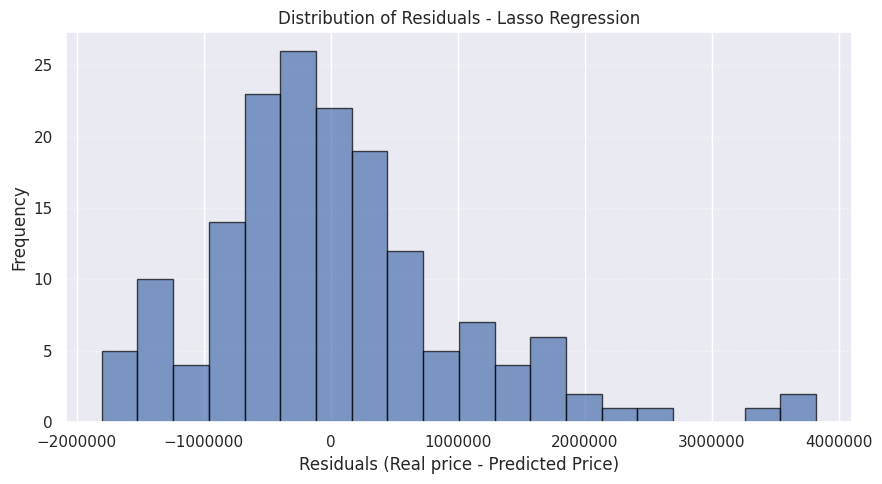


---- Generation Plot Residuals: ElasticNet ----


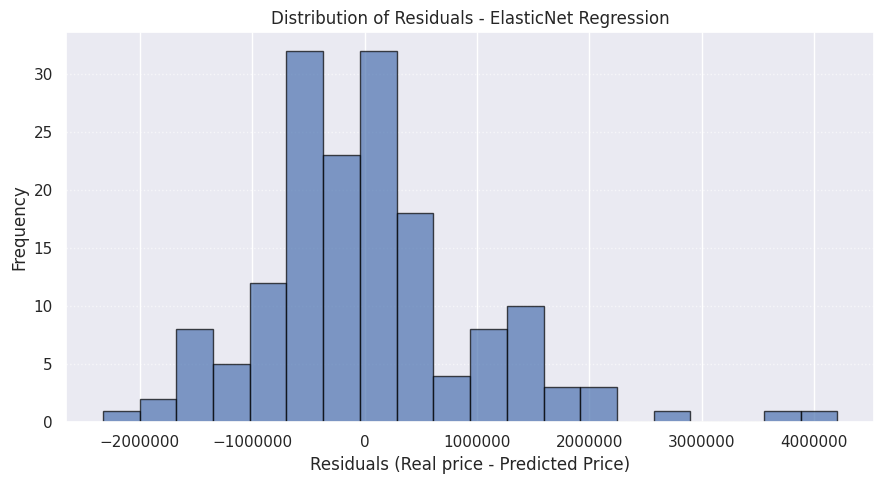

In [45]:
# Loop to analyze residuals of each model
for name, instance in models.items():
    print(f"\n---- Generation Plot Residuals: {name} ----")

    plot_residuals(
        model_instance=instance,
        model_name=name,
        X_train=X_train_cat2,
        X_test=X_test_cat2,
        y_train=y_train_cat2,
        y_test=y_test_cat2,
        target_scale=PRICE_SCALE
    )


### Residuals Comment:

From the analysis of the plots, it can be noted that although all three models exhibit a long right-hand tail, the majority of the errors are concentrated around values between -1 milione and +1 milione, resulting in a relatively concentrated and approximately symmetrical residual distribution.

Specifically:

- **Ridge**: it has the visually cleanest distribution and is the closest to a true Gaussian, with its highest peak (over 30 observations) exactly centered on the zero bar.

- **Lasso**: it is the least symmetrical plot. The main peak is slightly shifted to the left compared to zero, indicating a tendency to overestimate in the mid-range, and it also shows an unusual cluster of errors around -1.500.000 in the left tail. This is a consequence of Lasso using only 28 non-zero coefficients after zeroing out many features.

- **ElasticNet**: it behaves very similarly to Ridge, showing a double symmetrical peak around zero.

In summary, Ridge and ElasticNet are the best performing under this aspect, whereas Lasso is less precise due to its high number of zero coefficients.